<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/machina_learning/lab%20-%20Linear%20Regression%20for%20Time%20Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression for Time Series

## Introduction

Every model so far in this course has assumed the samples are **independent and identically distributed** (i.i.d.). Time series data breaks that assumption completely: the observations are ordered, each one is correlated with its own past, and the whole series drifts over time.

This changes almost nothing about the *model* and almost everything about the *method*. We still fit $\hat{y} = \boldsymbol{\theta}^\top \mathbf{x}$ by least squares. But:

- a **random train/test split is invalid** — it lets the model see the future;
- **features must be built causally** — a rolling mean that includes today is a bug, not a feature;
- **$R^2$ is misleading**, and the honest benchmark is a naive forecast, not zero;
- **cross-validation must respect time**, which rules out `KFold(shuffle=True)`.

Each of these is a way to get an excellent validation score and a worthless model. This lab is mostly about not doing that.

### Learning objectives

By the end you will be able to split a time series correctly, build features that do not leak, compare a model against a real baseline, and tune a hyperparameter with rolling-origin cross-validation.

### What you will build

A daily-demand forecaster, from a naive baseline up to a regularised linear model with calendar features and lags.

### Prerequisites

Labs 1 (OLS) and 2 (regularisation). Nothing is downloaded — the series is generated in the notebook, so we know the true data-generating process and can check whether the model recovers it.

## Mathematical Background

### Notation

| Symbol | Meaning |
|--------|---------|
| $y_t$ | Value of the series at time $t$ |
| $T$ | Length of the observed series |
| $m$ | Seasonal period (here $m = 7$, a week of daily data) |
| $\mathcal{F}_t = \{y_1, \ldots, y_t\}$ | Information available at time $t$ |
| $\hat{y}_{t+1 \mid t}$ | Forecast of $y_{t+1}$ made using only $\mathcal{F}_t$ |
| $\mathbf{x}_t$ | Feature vector for time $t$ |

### The forecasting problem

We want a function $f$ such that

$$\hat{y}_{t+1 \mid t} = f(\mathbf{x}_t), \qquad \mathbf{x}_t \ \text{depends only on}\ \mathcal{F}_t.$$

That $\mid t$ is the whole discipline of the subject. **Every quantity inside $\mathbf{x}_t$ must have been knowable at time $t$.** A feature that uses $y_{t+1}$, or a scaler fitted on the whole series, breaks it — and the resulting error estimate is fiction.

### The model

We combine the recent past of the series with features of the calendar:

$$\hat{y}_{t+1} \;=\; \underbrace{\theta_0}_{\text{level}}
\;+\; \underbrace{\sum_{i \in L} \theta_i\, y_{t+1-i}}_{\text{lags}}
\;+\; \underbrace{\beta\, t}_{\text{trend}}
\;+\; \underbrace{\sum_{d} \gamma_d\, \mathbb{1}[\text{weekday} = d]}_{\text{weekly pattern}}
\;+\; \underbrace{\sum_{j} \delta_j\, \mathbb{1}[\text{month} = j]}_{\text{annual pattern}}$$

This is **linear in the parameters**, so it is fitted by exactly the ordinary least squares of Lab 1. The entire difference from previous labs is how $\mathbf{x}_t$ is built and how the model is validated.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit, KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## The Dataset

We simulate four years of **daily demand** for some product, with a known data-generating process:

$$y_t = \underbrace{100 + 0.03\,t}_{\text{linear trend}}
       + \underbrace{s_{\text{weekday}(t)}}_{\text{weekly pattern}}
       + \underbrace{15 \sin\!\left(\tfrac{2\pi t}{365.25} - 1.2\right)}_{\text{annual pattern}}
       + \underbrace{\eta_t}_{\text{noise}}$$

The noise is **autocorrelated**: $\eta_t = 0.65\,\eta_{t-1} + \varepsilon_t$, so today's noise carries over into tomorrow's. That is what makes the series realistic — and what makes naive validation dangerous, because consecutive days resemble each other.

In [2]:
N_DAYS = 4 * 365
dates = pd.date_range('2019-01-01', periods=N_DAYS, freq='D')
t = np.arange(N_DAYS)

# --- deterministic components -------------------------------------------------
trend = 100 + 0.03 * t

dow_effect = np.array([-4.0, -3.0, -1.0, 0.0, 6.0, 12.0, 8.0])   # Mon ... Sun
weekly = dow_effect[dates.dayofweek.to_numpy()]

yearly = 15 * np.sin(2 * np.pi * t / 365.25 - 1.2)

# --- autocorrelated noise: today's noise depends on yesterday's ---------------
PHI, SIGMA = 0.65, 5.0
eps = rng.normal(0, SIGMA, N_DAYS)
eta = np.zeros(N_DAYS)
for i in range(1, N_DAYS):
    eta[i] = PHI * eta[i - 1] + eps[i]

y = trend + weekly + yearly + eta

series = pd.DataFrame({'y': y, 't': t}, index=dates)
series.index.name = 'date'

print('--- Series ---')
print(f'  Period : {series.index.min().date()} to {series.index.max().date()}')
print(f'  Length : {len(series)} daily observations')
print(f'  Mean   : {series["y"].mean():.2f}    Std: {series["y"].std():.2f}')
series.head()

--- Series ---
  Period : 2019-01-01 to 2022-12-30
  Length : 1460 daily observations
  Mean   : 124.22    Std: 18.09


,y,t
date,,
2019-01-01,83.019414,0
2019-01-02,79.945059,1
2019-01-03,86.646961,2
2019-01-04,97.353230,3
2019-01-05,92.005168,4


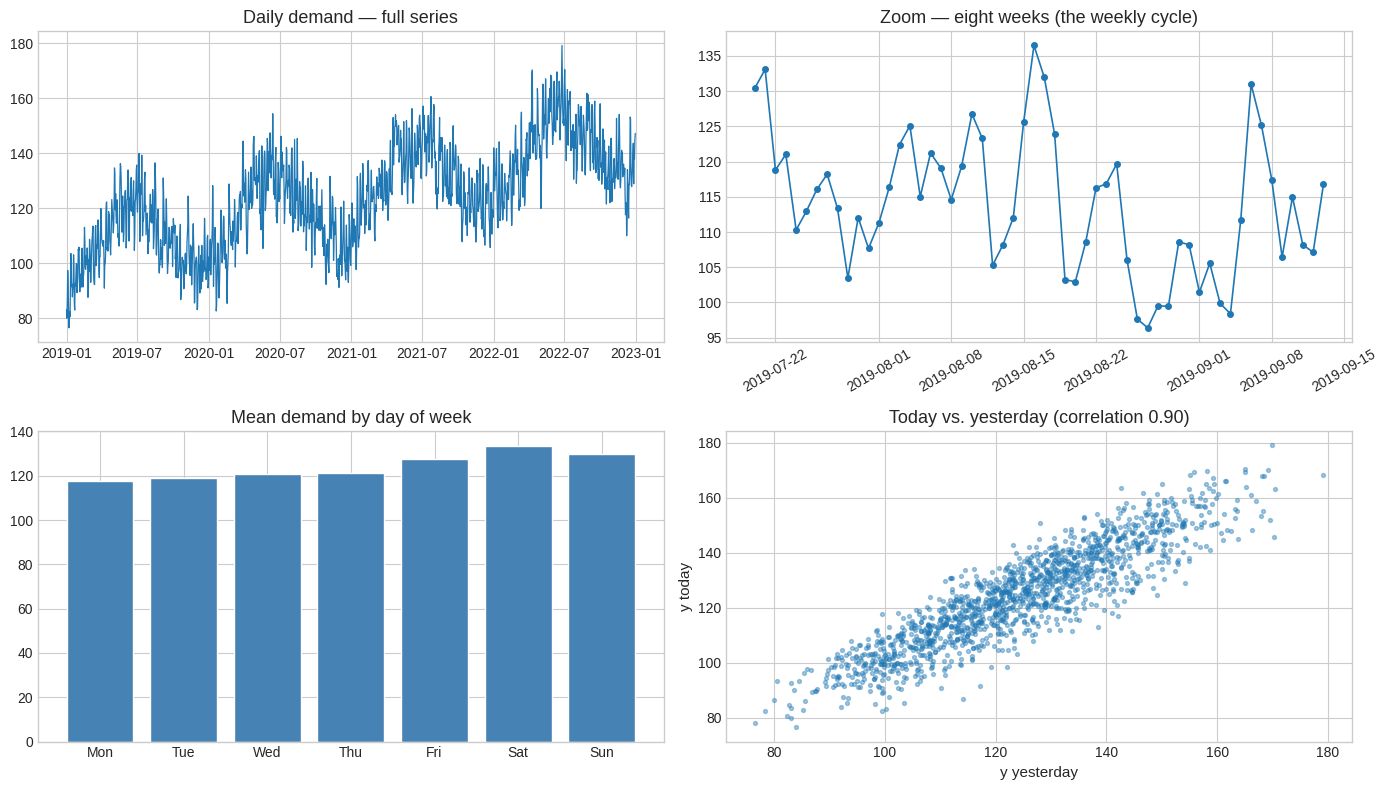

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(series.index, series['y'], lw=0.9)
axes[0, 0].set_title('Daily demand — full series', fontsize=13)

# Zoom on eight weeks: the weekly pattern is only visible at this scale
zoom = series.iloc[200:256]
axes[0, 1].plot(zoom.index, zoom['y'], marker='o', ms=4, lw=1.2)
axes[0, 1].set_title('Zoom — eight weeks (the weekly cycle)', fontsize=13)
axes[0, 1].tick_params(axis='x', rotation=30)

by_dow = series.groupby(series.index.dayofweek)['y'].mean()
axes[1, 0].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], by_dow.values,
               color='steelblue', edgecolor='white')
axes[1, 0].set_title('Mean demand by day of week', fontsize=13)

# Today against yesterday: the clearest possible picture of autocorrelation
axes[1, 1].scatter(series['y'].shift(1), series['y'], s=8, alpha=0.4)
axes[1, 1].set_xlabel('y yesterday', fontsize=11)
axes[1, 1].set_ylabel('y today', fontsize=11)
corr = series['y'].corr(series['y'].shift(1))
axes[1, 1].set_title(f'Today vs. yesterday (correlation {corr:.2f})', fontsize=13)

plt.tight_layout()
plt.show()

That last panel is the key to the whole lab. The correlation between consecutive days is very high: **if you know yesterday, you already know most of today.**

That is useful for forecasting — it is exactly the signal the lag features will exploit. But it is also a trap, and the next section shows why.

---
## The Cardinal Sin: Splitting at Random

Let us do the wrong thing deliberately, and measure how wrong it is.

We build a simple feature set, then evaluate the same model twice:

- **Split A (invalid):** `train_test_split(..., shuffle=True)` — the i.i.d. split used in every previous lab.
- **Split B (valid):** the last 20% of the series, in chronological order.

The model, the features and the data are identical. Only the split differs.

In [4]:
# A deliberately simple feature set for this demonstration: yesterday and last week.
demo = series.copy()
demo['lag_1'] = demo['y'].shift(1)
demo['lag_7'] = demo['y'].shift(7)
demo = demo.dropna()

X_demo = demo[['t', 'lag_1', 'lag_7']].to_numpy()
y_demo = demo['y'].to_numpy()

# --- Split A: random (INVALID for time series) --------------------------------
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
    X_demo, y_demo, test_size=0.2, shuffle=True, random_state=RANDOM_STATE
)
pred_a = LinearRegression().fit(Xa_tr, ya_tr).predict(Xa_te)

# --- Split B: chronological (VALID) -------------------------------------------
cut = int(len(X_demo) * 0.8)
Xb_tr, Xb_te = X_demo[:cut], X_demo[cut:]
yb_tr, yb_te = y_demo[:cut], y_demo[cut:]
pred_b = LinearRegression().fit(Xb_tr, yb_tr).predict(Xb_te)

print('--- Same model, same features, two different splits ---')
print(f'{"":<26}{"RMSE":>10}{"MAE":>10}{"R2":>10}')
for name, yt, yp in [('A  random split (WRONG)', ya_te, pred_a),
                     ('B  chronological split ', yb_te, pred_b)]:
    print(f'{name:<26}{mean_squared_error(yt, yp) ** 0.5:>10.3f}'
          f'{mean_absolute_error(yt, yp):>10.3f}{r2_score(yt, yp):>10.3f}')

--- Same model, same features, two different splits ---
                                RMSE       MAE        R2
A  random split (WRONG)        6.068     4.777     0.887
B  chronological split         7.152     5.771     0.658


The random split reports a better score. It always will, and for a reason that has nothing to do with the model being better:

> With a random split, the training set contains **day $t-1$ and day $t+1$** for a test point at day $t$. Given the autocorrelation we just plotted, that is close to being told the answer. Worse, the training set contains data from *after* the test point, so the model has been fitted on the future it is asked to predict.

The chronological number is the honest one. In a real project this gap is usually much larger than it is here, and it is the single most common reason a forecasting model that "validated beautifully" fails in production.

> ### Rule 1: never shuffle a time series.

---
## Splitting Properly

$$\underbrace{\big[\;\text{train}\;\big]}_{\text{fit parameters}}\;
\underbrace{\big[\;\text{validation}\;\big]}_{\text{choose the model}}\;
\underbrace{\big[\;\text{test}\;\big]}_{\text{touch once, at the end}}$$

The validation block is what you use while iterating: comparing feature sets, tuning $\alpha$, deciding whether lags help. The test block is opened once, when everything is decided. If you tune against the test set, its score becomes optimistic in exactly the way we just demonstrated.

Here we use two years for training, one year for validation and one year for test.

--- Chronological split ---
  train   731 days   2019-01-01 -> 2020-12-31
  val     365 days   2021-01-01 -> 2021-12-31
  test    364 days   2022-01-01 -> 2022-12-30


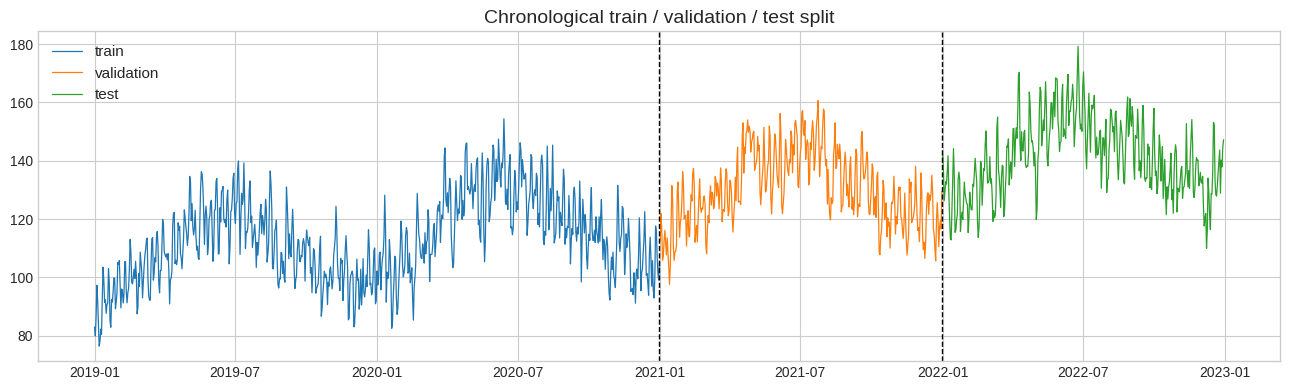

In [5]:
TRAIN_END = '2020-12-31'
VAL_END   = '2021-12-31'

train_idx = series.index <= TRAIN_END
val_idx   = (series.index > TRAIN_END) & (series.index <= VAL_END)
test_idx  = series.index > VAL_END

print('--- Chronological split ---')
for name, mask in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    sub = series.index[mask]
    print(f'  {name:<6}{len(sub):>5} days   {sub.min().date()} -> {sub.max().date()}')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(series.index[train_idx], series['y'][train_idx], lw=0.9, label='train')
ax.plot(series.index[val_idx],   series['y'][val_idx],   lw=0.9, label='validation')
ax.plot(series.index[test_idx],  series['y'][test_idx],  lw=0.9, label='test')
ax.axvline(pd.Timestamp(TRAIN_END), color='black', ls='--', lw=1)
ax.axvline(pd.Timestamp(VAL_END),   color='black', ls='--', lw=1)
ax.set_title('Chronological train / validation / test split', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## Baselines First

Before fitting anything, establish what "doing nothing" scores. In forecasting the standard baselines are:

| Baseline | Definition | When it is hard to beat |
|----------|------------|-------------------------|
| **Naive** | $\hat{y}_{t+1} = y_t$ | Random walks, financial series |
| **Seasonal naive** | $\hat{y}_{t+1} = y_{t+1-m}$ | Strong, stable seasonality |
| **Mean** | $\hat{y}_{t+1} = \bar{y}_{\text{train}}$ | Almost never — but it is the implicit baseline of $R^2$ |

A model that does not beat the seasonal naive forecast has learned nothing, no matter how good its $R^2$ looks.

In [6]:
y_all = series['y']

# Every baseline below is causal: the prediction for day t uses only days before t.
baseline_preds = {
    'Naive (y[t-1])':          y_all.shift(1),
    'Seasonal naive (y[t-7])': y_all.shift(7),
    'Train mean':              pd.Series(y_all[train_idx].mean(), index=y_all.index),
}

val_true = y_all[val_idx]
print('--- Baselines on the validation block ---')
print(f'{"":<26}{"MAE":>9}{"RMSE":>9}')
for name, pred in baseline_preds.items():
    p = pred[val_idx]
    print(f'{name:<26}{mean_absolute_error(val_true, p):>9.3f}'
          f'{mean_squared_error(val_true, p) ** 0.5:>9.3f}')

--- Baselines on the validation block ---
                                MAE     RMSE
Naive (y[t-1])                6.102    7.656
Seasonal naive (y[t-7])       7.787    9.768
Train mean                   18.056   21.426


---
## Measuring Properly

| Metric | Formula | Units | Notes |
|--------|---------|-------|-------|
| **MAE** | $\frac{1}{n}\sum \lvert e_t \rvert$ | same as $y$ | Robust, interpretable |
| **RMSE** | $\sqrt{\frac{1}{n}\sum e_t^2}$ | same as $y$ | Penalises large errors; it is what least squares minimises |
| **MASE** | $\dfrac{\text{MAE}}{\text{MAE of the seasonal naive forecast on the training set}}$ | ratio | **Scale-free: $<1$ beats the naive baseline, $>1$ loses to it** |

MASE is the one to decide with. Because its denominator is a fixed constant computed once on the training set, models evaluated on different periods stay comparable — and the number means something on its own, which "MAE = 4.1" does not.

### Why $R^2$ misleads here

$R^2$ compares your model to *predicting the training mean*. For a trending, seasonal series that baseline is absurdly weak, so $R^2$ sits close to 1 for models that are useless in practice. Report it if you like, but decide with MASE.

In [7]:
# Fixed denominator: seasonal-naive MAE on the TRAINING block only.
SEASON = 7
_train_y = y_all[train_idx].to_numpy()
MASE_SCALE = np.mean(np.abs(_train_y[SEASON:] - _train_y[:-SEASON]))
print(f'MASE scale (seasonal-naive MAE on train, m={SEASON}): {MASE_SCALE:.4f}\n')


def evaluate(y_true, y_pred, name='model'):
    """Return the standard forecasting metrics as a dict."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    return {
        'model': name,
        'MAE':  np.mean(np.abs(err)),
        'RMSE': np.sqrt(np.mean(err ** 2)),
        'MASE': np.mean(np.abs(err)) / MASE_SCALE,
        'R2':   r2_score(y_true, y_pred),
    }


scoreboard = [evaluate(val_true, pred[val_idx], name)
              for name, pred in baseline_preds.items()]
pd.DataFrame(scoreboard).set_index('model').round(3)

MASE scale (seasonal-naive MAE on train, m=7): 7.4885



,MAE,RMSE,MASE,R2
model,,,,
Naive (y[t-1]),6.102,7.656,0.815,0.630
Seasonal naive (y[t-7]),7.787,9.768,1.040,0.397
Train mean,18.056,21.426,2.411,-1.902


Read the `R2` column against the `MASE` column. The seasonal-naive forecast has an $R^2$ that would look respectable in any other lab, while its MASE of about 1.0 says exactly what it should: this is simply the bar to beat. The train-mean baseline has $R^2 \approx 0$, which is what $R^2$ is defined to give it.

(Its MASE is 1.04 rather than precisely 1.00 because the denominator is fixed on the *training* block while this row is measured on *validation* — the seasonal naive is slightly harder in the validation year. That is the point of a fixed denominator: the scale does not move when the evaluation period does.)

> ### Rule 2: report a scale-free metric against a real baseline.

---
## Feature Engineering, Causally

### The look-ahead bug

This is the mistake to internalise. Consider a 7-day rolling mean:

```python
df['roll7'] = df['y'].rolling(7).mean()          # WRONG
df['roll7'] = df['y'].shift(1).rolling(7).mean() # RIGHT
```

The first version's window **ends at day $t$ and therefore includes $y_t$** — the value being predicted. The model learns to invert the average and recover the target. Training error collapses, validation error looks superb as long as the same bug is present in the validation features, and the model fails completely in production where $y_t$ is not yet known.

Look at the numbers directly.

In [8]:
peek = pd.DataFrame({'y': y_all.iloc[:8]})
peek['roll3_WRONG'] = peek['y'].rolling(3).mean()             # includes y[t]
peek['roll3_RIGHT'] = peek['y'].shift(1).rolling(3).mean()    # ends at y[t-1]
peek.round(2)

,y,roll3_WRONG,roll3_RIGHT
date,,,
2019-01-01,83.02,NaN,NaN
2019-01-02,79.95,NaN,NaN
2019-01-03,86.65,83.20,NaN
2019-01-04,97.35,87.98,83.20
2019-01-05,92.01,92.00,87.98
2019-01-06,83.93,91.09,92.00
2019-01-07,76.48,84.14,91.09
2019-01-08,78.27,79.56,84.14


In [9]:
# The consequence, quantified. We give the model lags 1-6 plus a 7-day rolling mean.
leak = series.copy()
for L in range(1, 7):
    leak[f'lag_{L}'] = leak['y'].shift(L)
leak['roll7_wrong'] = leak['y'].rolling(7).mean()          # window ends at t   -> leaks
leak['roll7_right'] = leak['y'].shift(1).rolling(7).mean() # window ends at t-1 -> fine
leak = leak.dropna()

l_tr = leak.index <= TRAIN_END
l_va = (leak.index > TRAIN_END) & (leak.index <= VAL_END)
lag_cols = [f'lag_{L}' for L in range(1, 7)]

print('--- One feature, two definitions ---')
for col in ['roll7_wrong', 'roll7_right']:
    cols = lag_cols + [col]
    m = LinearRegression().fit(leak.loc[l_tr, cols], leak.loc[l_tr, 'y'])
    s = evaluate(leak.loc[l_va, 'y'], m.predict(leak.loc[l_va, cols]), col)
    print(f'  {col:<12} MAE={s["MAE"]:8.4f}   MASE={s["MASE"]:7.4f}   R2={s["R2"]:8.5f}')

print('\n  The leaking model is not good. It is cheating: since')
print('    roll7_wrong = (y[t] + y[t-1] + ... + y[t-6]) / 7')
print('  and lags 1-6 are also features, least squares can solve for y[t] exactly:')
print('    y[t] = 7 * roll7_wrong - (y[t-1] + ... + y[t-6])')
print('  It has not learned to forecast. It has learned to do arithmetic.')

--- One feature, two definitions ---
  roll7_wrong  MAE=  0.0000   MASE= 0.0000   R2= 1.00000
  roll7_right  MAE=  4.9994   MASE= 0.6676   R2= 0.74756

  The leaking model is not good. It is cheating: since
    roll7_wrong = (y[t] + y[t-1] + ... + y[t-6]) / 7
  and lags 1-6 are also features, least squares can solve for y[t] exactly:
    y[t] = 7 * roll7_wrong - (y[t-1] + ... + y[t-6])
  It has not learned to forecast. It has learned to do arithmetic.


> ### Rule 3: every rolling feature must be `shift(1)`-ed before the window.

### The feature set

| Group | Features | Captures |
|-------|----------|----------|
| Trend | `t` | Long-run growth |
| Month | 11 month dummies (January is the reference) | Annual cycle |
| Weekday | 6 day-of-week dummies (Monday is the reference) | Weekly pattern |
| Lags | $y_{t-1}, y_{t-2}, y_{t-3}, y_{t-7}, y_{t-14}$ | Autocorrelation, short-term momentum |
| Rolling | mean of the previous 7 and 28 days | Local level |

**Why drop one dummy?** Twelve month dummies plus an intercept are perfectly collinear (they always sum to 1), so $\mathbf{X}^\top\mathbf{X}$ is singular and the fit is not unique. Dropping one level makes the remaining coefficients differences *relative to that reference*. The same argument applies to the weekday dummies.

**Why are calendar features safe?** Unlike lags, the month and weekday of a future date are known arbitrarily far in advance — no shifting required.

In [10]:
LAGS = [1, 2, 3, 7, 14]
ROLL_WINDOWS = [7, 28]


def build_features(df, lags=LAGS, roll_windows=ROLL_WINDOWS):
    """Build a causal design matrix from a frame with columns ['y', 't'].

    Every column is computable from information strictly before the row's own
    date, except the calendar columns, which are known arbitrarily far ahead.
    """
    X = pd.DataFrame(index=df.index)

    # --- calendar: known for any future date ---
    X['trend'] = df['t']
    for month in range(2, 13):                  # month 1 (January) is the reference
        X[f'month_{month}'] = (df.index.month == month).astype(float)
    for d in range(1, 7):                       # d = 0 (Monday) is the reference
        X[f'dow_{d}'] = (df.index.dayofweek == d).astype(float)

    # --- lags: strictly past values ---
    for L in lags:
        X[f'lag_{L}'] = df['y'].shift(L)

    # --- rolling: shift(1) FIRST, then the window ---
    for w in roll_windows:
        X[f'rmean_{w}'] = df['y'].shift(1).rolling(w).mean()

    return X


X_all = build_features(series)
design = X_all.join(series['y']).dropna()       # drop warm-up rows with NaN lags

# Re-derive the masks on the trimmed index so every model below uses the same rows.
d_train = design.index <= TRAIN_END
d_val   = (design.index > TRAIN_END) & (design.index <= VAL_END)
d_test  = design.index > VAL_END

FEATURES = list(X_all.columns)
CALENDAR = [c for c in FEATURES if c.startswith(('trend', 'month_', 'dow_'))]

X_tr, y_tr = design.loc[d_train, FEATURES], design.loc[d_train, 'y']
X_va, y_va = design.loc[d_val,   FEATURES], design.loc[d_val,   'y']
X_te, y_te = design.loc[d_test,  FEATURES], design.loc[d_test,  'y']

print(f'--- Design matrix ---')
print(f'  Features : {len(FEATURES)}   (of which {len(CALENDAR)} calendar)')
print(f'  Rows     : {len(design)} (lost {len(series) - len(design)} to the warm-up window)')
print(f'  train {X_tr.shape}   val {X_va.shape}   test {X_te.shape}')
design[['trend', 'month_2', 'dow_1', 'lag_1', 'rmean_7', 'y']].head(3).round(2)

--- Design matrix ---
  Features : 25   (of which 18 calendar)
  Rows     : 1432 (lost 28 to the warm-up window)
  train (703, 25)   val (365, 25)   test (364, 25)


,trend,month_2,dow_1,lag_1,rmean_7,y
date,,,,,,
2019-01-29,28,0.0,1.0,89.28,92.98,91.68
2019-01-30,29,0.0,0.0,91.68,94.23,94.76
2019-01-31,30,0.0,0.0,94.76,94.55,105.10


---
## Fitting

### Model 1 — calendar only

Trend, month dummies and weekday dummies; no information from the series itself. This is a pure *regression on time*, and it can forecast arbitrarily far ahead because all of its features are known in advance.

Because we generated the data ourselves, we can check the fitted coefficients against the truth — the best possible sanity check that the feature construction is correct. If a model cannot recover parameters from data you generated yourself, the bug is in your code.

In [11]:
results = []

m1 = LinearRegression().fit(X_tr[CALENDAR], y_tr)
p1_va = m1.predict(X_va[CALENDAR])
results.append(evaluate(y_va, p1_va, '1. Calendar only'))

print('--- Recovered coefficients vs. the true generating process ---')
print(f'  trend  : {m1.coef_[CALENDAR.index("trend")]:.4f}   (true 0.0300)')
for d, day in zip(range(1, 7), ['Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']):
    true_effect = dow_effect[d] - dow_effect[0]
    est = m1.coef_[CALENDAR.index(f'dow_{d}')]
    print(f'  {day} vs Mon : {est:6.2f}   (true {true_effect:5.2f})')

--- Recovered coefficients vs. the true generating process ---
  trend  : 0.0262   (true 0.0300)
  Tue vs Mon :   1.98   (true  1.00)
  Wed vs Mon :   4.02   (true  3.00)
  Thu vs Mon :   4.85   (true  4.00)
  Fri vs Mon :  11.11   (true 10.00)
  Sat vs Mon :  16.70   (true 16.00)
  Sun vs Mon :  12.83   (true 12.00)


The trend and the shape of the weekday pattern both come out close to the truth. Notice, though, that **all six weekday estimates sit about 1 unit above their true values.** That is not six independent errors — it is one. Every coefficient is a contrast *relative to Monday*, so whatever error there is in Monday's own estimated level is shared by all six. With roughly 100 Mondays in the training block and noisy data, that offset is ordinary sampling variation.

This is worth remembering whenever you read dummy-variable coefficients: they are differences from a reference level, never absolute effects, and they move together when the reference moves.

### Model 2 — adding lags

Now the autoregressive terms. These carry the autocorrelated noise, which the calendar model cannot represent at all.

In [12]:
m2 = LinearRegression().fit(X_tr, y_tr)
results.append(evaluate(y_va, m2.predict(X_va), '2. + lags and rolling means'))

pd.DataFrame(results).set_index('model').round(3)

,MAE,RMSE,MASE,R2
model,,,,
1. Calendar only,5.995,7.593,0.801,0.636
2. + lags and rolling means,3.880,4.990,0.518,0.843


### Model 3 — regularisation, scaled correctly

The lag and rolling features are strongly correlated with each other, which inflates the variance of the OLS coefficients (Lab 2). Ridge handles that. Two details matter:

1. Ridge penalises $\lVert \boldsymbol{\theta} \rVert_2^2$, so features must be on a **comparable scale** — `trend` runs to 1460 while the dummies are 0/1.
2. The scaler is **fitted on the training block only**, inside a `Pipeline`. Fitting it on the full series would leak the mean and variance of the future into training.

In [13]:
m3 = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X_tr, y_tr)
p3_va = m3.predict(X_va)
results.append(evaluate(y_va, p3_va, '3. Ridge (alpha=1, scaled)'))

pd.DataFrame(results).set_index('model').round(3)

,MAE,RMSE,MASE,R2
model,,,,
1. Calendar only,5.995,7.593,0.801,0.636
2. + lags and rolling means,3.880,4.990,0.518,0.843
"3. Ridge (alpha=1, scaled)",3.870,4.984,0.517,0.843


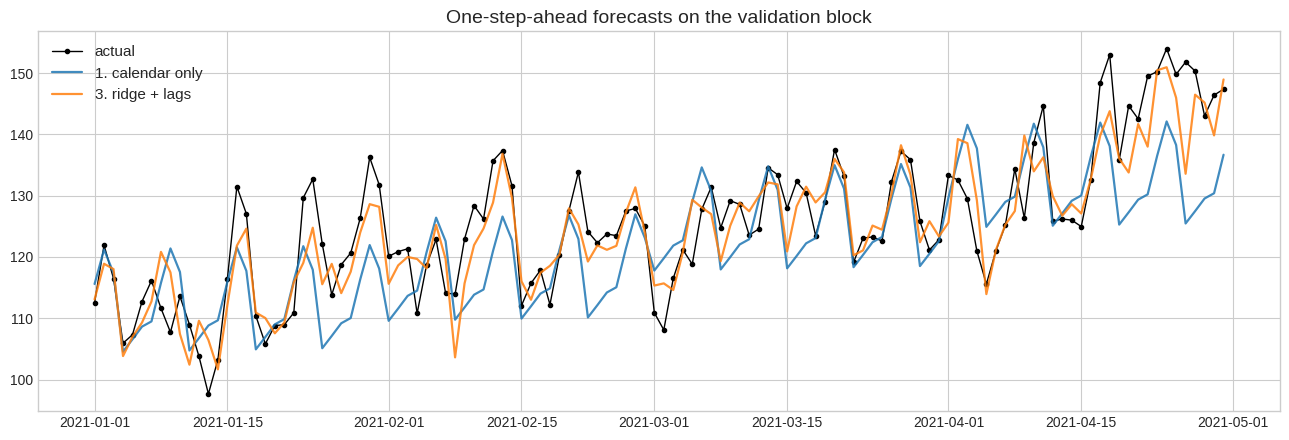

In [14]:
fig, ax = plt.subplots(figsize=(13, 4.5))
window = slice(0, 120)                          # first four months of validation
ax.plot(y_va.index[window], y_va.values[window], 'o-', ms=3, lw=1,
        color='black', label='actual')
ax.plot(y_va.index[window], p1_va[window], lw=1.6, alpha=0.85, label='1. calendar only')
ax.plot(y_va.index[window], p3_va[window], lw=1.6, alpha=0.85, label='3. ridge + lags')
ax.set_title('One-step-ahead forecasts on the validation block', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## Cross-Validation That Respects Time

A single validation block gives one noisy estimate that depends heavily on which year happened to be held out. The time-series analogue of $k$-fold is **rolling-origin evaluation**: repeatedly train on everything up to a point and validate on what follows.

```
fold 1  [=====train=====][val]
fold 2  [========train========][val]
fold 3  [===========train===========][val]
fold 4  [==============train==============][val]
```

The training window **expands** and the origin rolls forward. Each fold answers "if I had stood here, how would the model have done next?" — the question you actually care about. `TimeSeriesSplit` implements this.

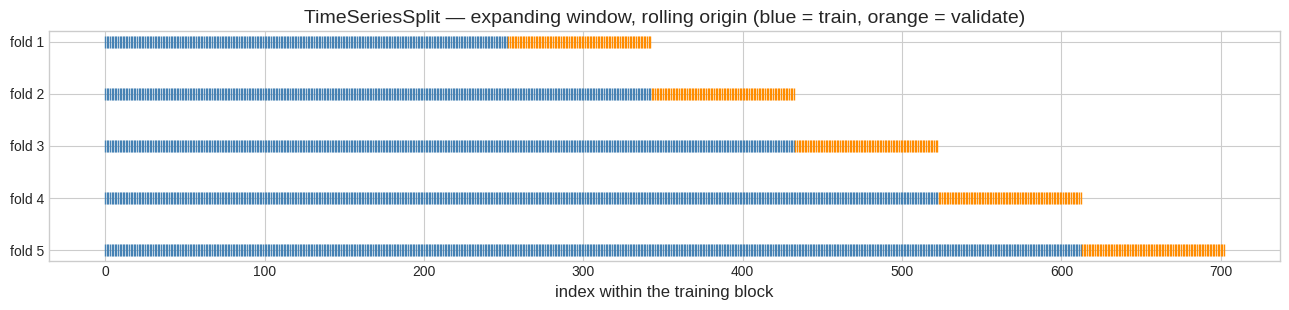

In [15]:
tscv = TimeSeriesSplit(n_splits=5, test_size=90)

fig, ax = plt.subplots(figsize=(13, 3.2))
for i, (tr, va) in enumerate(tscv.split(X_tr)):
    ax.plot(tr, np.full_like(tr, i, dtype=float), '|', color='steelblue', ms=8)
    ax.plot(va, np.full_like(va, i, dtype=float), '|', color='darkorange', ms=8)
ax.set_yticks(range(5))
ax.set_yticklabels([f'fold {i+1}' for i in range(5)])
ax.set_xlabel('index within the training block', fontsize=12)
ax.set_title('TimeSeriesSplit — expanding window, rolling origin '
             '(blue = train, orange = validate)', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Tuning $\alpha$ — and what `KFold(shuffle=True)` would have told us

We select the ridge penalty by rolling-origin CV **inside the training block**, then confirm on the untouched validation block. For contrast we run the same search with a shuffled `KFold`, the tool used in every previous lab.

--- Selected penalty ---
  TimeSeriesSplit : alpha =   12.1153   CV MAE = 4.832
  Shuffled KFold  : alpha =    0.8254   CV MAE = 4.088  <- optimistic


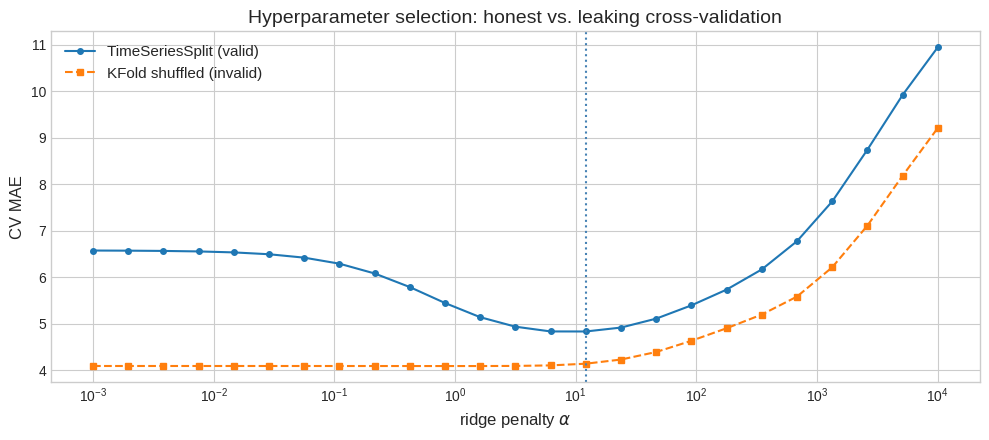

In [16]:
ALPHAS = np.logspace(-3, 4, 25)


def cv_mae(alphas, splitter, X, y):
    """Mean CV MAE for each alpha under a given splitter."""
    scores = []
    for a in alphas:
        fold_scores = []
        for tr, va in splitter.split(X):
            pipe = make_pipeline(StandardScaler(), Ridge(alpha=a))
            pipe.fit(X.iloc[tr], y.iloc[tr])
            fold_scores.append(mean_absolute_error(y.iloc[va], pipe.predict(X.iloc[va])))
        scores.append(np.mean(fold_scores))
    return np.array(scores)


mae_ts = cv_mae(ALPHAS, TimeSeriesSplit(n_splits=5, test_size=90), X_tr, y_tr)
mae_kf = cv_mae(ALPHAS, KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), X_tr, y_tr)

best_ts = ALPHAS[np.argmin(mae_ts)]
best_kf = ALPHAS[np.argmin(mae_kf)]

print('--- Selected penalty ---')
print(f'  TimeSeriesSplit : alpha = {best_ts:9.4f}   CV MAE = {mae_ts.min():.3f}')
print(f'  Shuffled KFold  : alpha = {best_kf:9.4f}   CV MAE = {mae_kf.min():.3f}  <- optimistic')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.semilogx(ALPHAS, mae_ts, 'o-', ms=4, label='TimeSeriesSplit (valid)')
ax.semilogx(ALPHAS, mae_kf, 's--', ms=4, label='KFold shuffled (invalid)')
ax.axvline(best_ts, color='steelblue', ls=':', lw=1.5)
ax.set_xlabel(r'ridge penalty $\alpha$', fontsize=12)
ax.set_ylabel('CV MAE', fontsize=12)
ax.set_title('Hyperparameter selection: honest vs. leaking cross-validation', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The shuffled curve sits below the honest one at every $\alpha$: it is systematically optimistic, because each fold's training data surrounds its validation data in time. Note also that it can select a **different** $\alpha$ — leakage does not merely mis-report performance, it can make you choose the wrong model.

> ### Rule 4: cross-validate with a rolling origin.

In [17]:
m4 = make_pipeline(StandardScaler(), Ridge(alpha=best_ts)).fit(X_tr, y_tr)
p4_va = m4.predict(X_va)
results.append(evaluate(y_va, p4_va, f'4. Ridge (alpha={best_ts:.3g}, TS-CV)'))

pd.DataFrame(results).set_index('model').round(3)

,MAE,RMSE,MASE,R2
model,,,,
1. Calendar only,5.995,7.593,0.801,0.636
2. + lags and rolling means,3.880,4.990,0.518,0.843
"3. Ridge (alpha=1, scaled)",3.870,4.984,0.517,0.843
"4. Ridge (alpha=12.1, TS-CV)",3.842,4.994,0.513,0.842


---
## Residual Diagnostics

For a well-specified forecaster the residuals should look like noise: centred on zero, with no visible pattern. Any structure left in them is signal the model failed to capture — and therefore an opportunity.

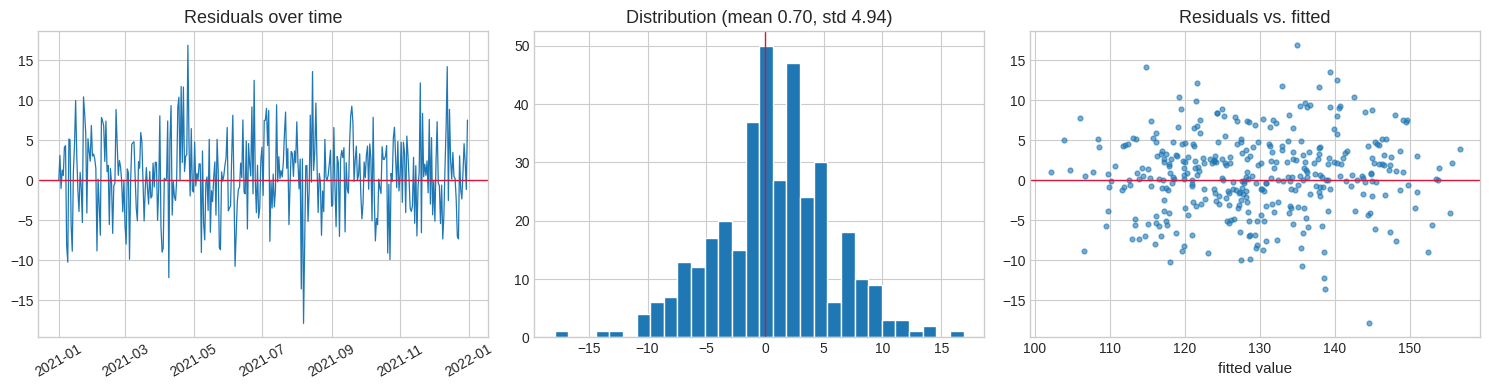

Mean residual: +0.700   (should be close to 0)


In [18]:
resid = y_va.to_numpy() - p4_va

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(y_va.index, resid, lw=0.9)
axes[0].axhline(0, color='crimson', lw=1)
axes[0].set_title('Residuals over time', fontsize=13)
axes[0].tick_params(axis='x', rotation=30)

axes[1].hist(resid, bins=30, edgecolor='white')
axes[1].axvline(0, color='crimson', lw=1)
axes[1].set_title(f'Distribution (mean {resid.mean():.2f}, std {resid.std():.2f})', fontsize=13)

axes[2].scatter(p4_va, resid, s=12, alpha=0.6)
axes[2].axhline(0, color='crimson', lw=1)
axes[2].set_xlabel('fitted value', fontsize=11)
axes[2].set_title('Residuals vs. fitted', fontsize=13)

plt.tight_layout()
plt.show()

print(f'Mean residual: {resid.mean():+.3f}   (should be close to 0)')

What to look for in those three panels:

- **A non-zero mean** says the model systematically over- or under-forecasts. Look back at the recovered trend coefficient: fitted on two years and applied to the third, even a small shortfall accumulates into a persistent bias — one that no MAE or MASE number would have revealed.
- **A funnel shape** in residuals-vs-fitted means the error grows with the level of the series (heteroscedasticity), and a log transform is the usual next move.
- **A visible pattern over time** means there is seasonal or trend structure the model has not absorbed.

### The danger of extrapolating a linear trend

The `trend` coefficient is fitted on the training range and then applied to dates outside it. Over a year that is usually fine; over ten it is a promise that growth continues forever at exactly the same rate. Here is what the calendar model claims about 2027.

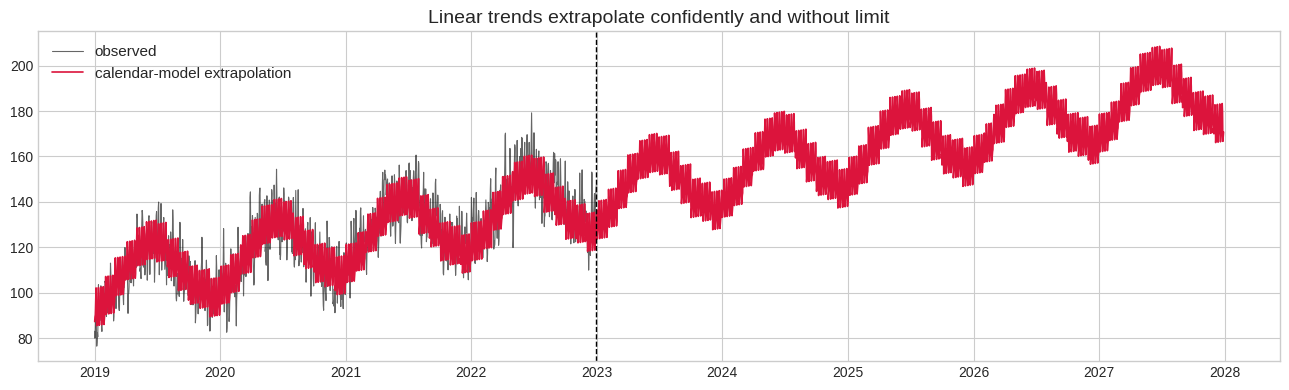

Predicted demand on 2027-12-29: 170.7   (last observed: 147.2)


In [19]:
far_dates = pd.date_range('2019-01-01', periods=int(9 * 365), freq='D')
far = pd.DataFrame({'y': np.nan, 't': np.arange(len(far_dates))}, index=far_dates)
far_pred = m1.predict(build_features(far)[CALENDAR])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(series.index, series['y'], lw=0.8, label='observed', color='black', alpha=0.6)
ax.plot(far_dates, far_pred, lw=1.2, color='crimson', label='calendar-model extrapolation')
ax.axvline(series.index[-1], color='black', ls='--', lw=1)
ax.set_title('Linear trends extrapolate confidently and without limit', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Predicted demand on {far_dates[-1].date()}: {far_pred[-1]:.1f}'
      f'   (last observed: {series["y"].iloc[-1]:.1f})')

Nothing in the mathematics prevents this, and nothing in the validation score warns you about it — the validation block is inside the range where the trend still holds. A linear trend is a modelling *assumption* about the future, not a fact learned from data.

### One step ahead is not always the problem you have

Everything in this lab forecasts $h = 1$: predict tomorrow, given everything up to today. That is the easiest version of the task. If you need to plan stock for the next month you need $h = 1, \ldots, 30$ — and at $h = 30$ the `lag_1` feature does not exist yet, because $y_{t+29}$ has not happened.

The two standard remedies are to forecast one step and feed the prediction back in as though it were observed (*recursive*), or to train a separate model per horizon (*direct*). Both are beyond this lab, but the consequence is not: **error grows with the horizon**, so a model reported as "MAE 4.1" without stating $h$ is not reporting anything.

> ### Rule 5: validate at the horizon you will actually deploy.

---
## The Final Evaluation

The test block has not been touched. We now refit the chosen model on **train + validation** — using all available history is standard once the model is fixed — and score it once.

,MAE,RMSE,MASE,R2
model,,,,
Seasonal naive (baseline),8.465,10.538,1.130,0.346
Final ridge model (h=1),4.290,5.361,0.573,0.831


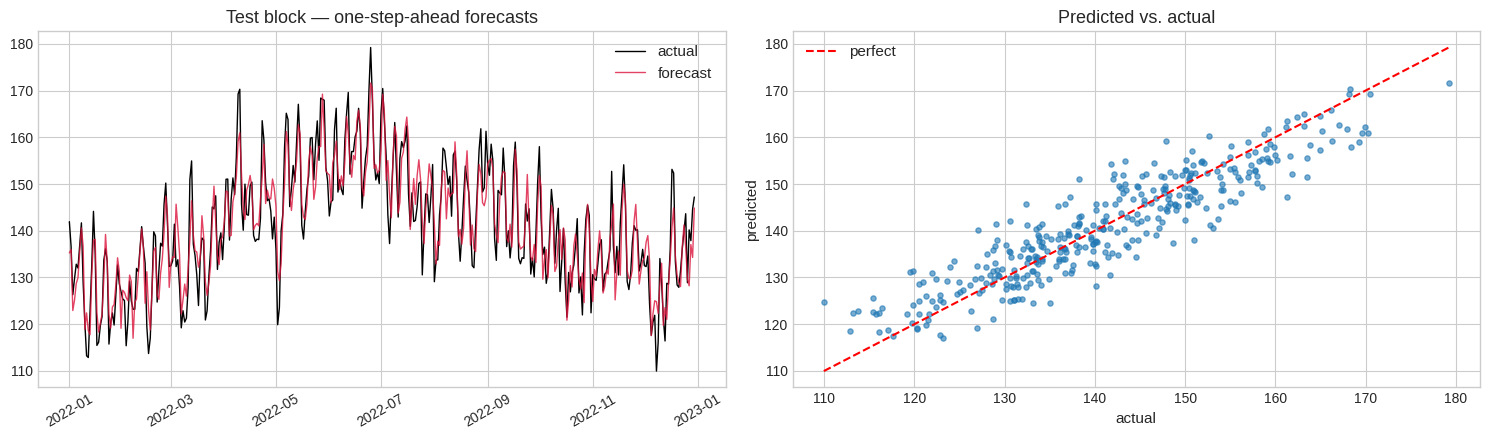

In [20]:
X_full = design.loc[d_train | d_val, FEATURES]
y_full = design.loc[d_train | d_val, 'y']

final_model = make_pipeline(StandardScaler(), Ridge(alpha=best_ts)).fit(X_full, y_full)
p_test = final_model.predict(X_te)

seasonal_naive_test = series['y'].shift(7).loc[X_te.index]

final = pd.DataFrame([
    evaluate(y_te, seasonal_naive_test, 'Seasonal naive (baseline)'),
    evaluate(y_te, p_test, 'Final ridge model (h=1)'),
]).set_index('model')
display(final.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(y_te.index, y_te.values, lw=1, color='black', label='actual')
axes[0].plot(y_te.index, p_test, lw=1, color='crimson', alpha=0.8, label='forecast')
axes[0].set_title('Test block — one-step-ahead forecasts', fontsize=13)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=11)

axes[1].scatter(y_te, p_test, s=14, alpha=0.6)
lims = [y_te.min(), y_te.max()]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='perfect')
axes[1].set_xlabel('actual', fontsize=11)
axes[1].set_ylabel('predicted', fontsize=11)
axes[1].set_title('Predicted vs. actual', fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

Report the result as: *"MASE of X at horizon 1, on a held-out year, against a seasonal naive baseline."* Every part of that sentence is load-bearing.

---
## Exercise — Feature ablation

Which feature group is actually earning its place? Refit model 4 several times, each time removing one group (`trend`, month dummies, day-of-week dummies, lags, rolling means), and report the validation MASE of each. Which removal hurts most?

In [21]:
# Your turn:

<details><summary><b>Solution</b></summary>Run the cell below.</details>

In [22]:
groups = {
    'trend':   ['trend'],
    'month':   [c for c in FEATURES if c.startswith('month_')],
    'dow':     [c for c in FEATURES if c.startswith('dow_')],
    'lags':    [c for c in FEATURES if c.startswith('lag_')],
    'rolling': [c for c in FEATURES if c.startswith('rmean_')],
}

rows = [evaluate(y_va, m4.predict(X_va), 'all features')]
for name, cols in groups.items():
    keep = [c for c in FEATURES if c not in cols]
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=best_ts)).fit(X_tr[keep], y_tr)
    rows.append(evaluate(y_va, mdl.predict(X_va[keep]), f'without {name}'))

ablation = pd.DataFrame(rows).set_index('model')[['MAE', 'MASE']]
ablation['MASE delta'] = (ablation['MASE'] - ablation.loc['all features', 'MASE']).round(4)
ablation.round(3)

,MAE,MASE,MASE delta
model,,,
all features,3.842,0.513,0.000
without trend,3.956,0.528,0.015
without month,4.015,0.536,0.023
without dow,4.894,0.654,0.140
without lags,5.248,0.701,0.188
without rolling,3.879,0.518,0.005


## Reflection Questions

1. **The leaking split.** The random split scored *better* than the chronological one. Why is a better score evidence of a worse experiment here?

2. **MASE vs $R^2$.** The seasonal naive baseline has a high $R^2$ and a MASE of about 1.0. Explain why both numbers are correct and why only one of them is useful.

3. **The rolling-mean bug.** `df['y'].rolling(7).mean()` gave a near-perfect validation score. If you deployed that model tomorrow morning, what exactly would go wrong?

4. **Dummy variables.** We used 11 month dummies, not 12. What would happen to $\mathbf{X}^\top\mathbf{X}$ if we used all 12 alongside an intercept?

5. **Trend extrapolation.** The validation score gave no warning about the 2027 forecast. What does that tell you about the limits of held-out validation?

## Answers

**1. The leaking split.** The score is better because the task was made easier, not because the model was. A randomly chosen test day has its immediate neighbours in the training set, and consecutive days are correlated at about 0.97 — so the answer is nearly given away. The training set also contains days *after* the test day, which no deployed model will ever have. A validation setup that is easier than deployment produces a number that cannot be trusted, and the direction of the error is always flattering.

**2. MASE vs $R^2$.** (The seasonal naive scores 1.04 rather than 1.00 because its MASE denominator is fixed on the training block.) $R^2$ measures improvement over *predicting the training mean*. For a series with a trend and strong seasonality, the mean is a terrible predictor, so beating it is easy and $R^2$ is close to 1 for anything. MASE measures improvement over the *seasonal naive* forecast, which is a genuinely competitive predictor for seasonal data. Both are arithmetically correct; only MASE compares against a bar worth clearing.

**3. The rolling-mean bug.** `roll7` computed at day $t$ includes $y_t$ itself, and since the lags $y_{t-1} \ldots y_{t-6}$ are also features, the model can solve $y_t = 7\cdot\text{roll7} - (y_{t-1} + \cdots + y_{t-6})$ exactly. In deployment you must compute the features *before* $y_t$ is observed — so the number you would feed in does not exist. Either the pipeline crashes, or you unknowingly supply yesterday's window and the model, which learned arithmetic rather than forecasting, produces nonsense.

**4. Dummy variables.** The 12 month dummies sum to 1 in every row, which is exactly the intercept column. The columns are therefore linearly dependent, $\mathbf{X}^\top\mathbf{X}$ is singular, and the OLS solution $(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ does not exist — infinitely many coefficient vectors give the same fit. (Ridge would still return an answer, because the penalty makes the problem well-posed again, but the individual coefficients would not be interpretable on their own.)

**5. Trend extrapolation.** Held-out validation only tests the model *inside the range of the data you have*. The validation year sits in a period where the linear trend still holds, so no split, however careful, could have warned you about 2027. Validation checks that you learned the data correctly; it cannot check that the assumptions keep holding outside it. That part is a judgement call, and it stays the analyst's responsibility.

---
## Summary

### The five rules

1. **Never shuffle.** Split chronologically; the validation block always follows the training block in time.
2. **Build features causally.** `shift(1)` before every rolling window, and ask of every column: *was this knowable on that date?*
3. **Beat a real baseline.** Report MASE against the seasonal naive forecast. $R^2$ flatters trending series.
4. **Cross-validate with a rolling origin.** Use `TimeSeriesSplit`, never `KFold(shuffle=True)`.
5. **Validate at your deployment horizon.** One-step-ahead accuracy says little about $h = 30$.

### Checklist for your own projects

- [ ] Is the data sorted by time, with no duplicated or missing timestamps?
- [ ] Does any feature use information from time $> t$?
- [ ] Was the scaler (and any imputer or encoder) fitted on the training fold only?
- [ ] Is the test block untouched until the model is final?
- [ ] Does the model beat naive and seasonal naive?
- [ ] Are you extrapolating a trend beyond the range where you believe it?

### Where to go next

This lab deliberately stays inside linear regression, so that every effect is attributable to methodology rather than to model capacity. The same splitting, validation and metric discipline transfers unchanged to:

- **Classical statistical models** — ARIMA, ETS (`statsmodels`).
- **Gradient boosting on lag features** — usually the strongest tabular forecaster in practice, and a direct extension of Lab 6.
- **Deep learning** — the RNN/LSTM machinery of Lab 11, applied to numeric sequences.

Whatever the model, the leakage traps in this notebook are the same, and they are what separates a forecast from a good-looking backtest.